# E12 Matrix Factorization Scale-Imbalance Preconditioning

### Problem

This notebook tests whether spectral orthogonalization acts as a preconditioner in ten-factor matrix factorization. The represented model is

$$\widehat X=W_1W_2\cdots W_{10},\qquad g(W_{1:10})=\frac{1}{2d^2}\lVert W_1W_2\cdots W_{10}-X^\star\rVert_F^2.$$

The first and last factors are initialized with explicit scales while the middle factors start at identity, so severe endpoint scale imbalance creates a natural hard regime. The hypothesis is that exact or low-order polar Muon variants can improve recovery under this imbalance, especially as target condition number increases.


### Metric And Function Definitions

The plots and tables use these diagnostics. They are defined here so symbols like `srank()` are not left implicit.

Let the singular values of a matrix $M$ be $\sigma_1\ge\sigma_2\ge\cdots\ge0$.

| name in notebook/code | definition | how to read it |
|---|---|---|
| `srank(M)` / `stable_rank(M)` | $\operatorname{srank}(M)=\lVert M\rVert_F^2/(\lVert M\rVert_{op}^2+\epsilon)=\sum_i\sigma_i^2/(\sigma_1^2+\epsilon)$ | Soft dimension based on energy; high means energy is spread over many singular directions. |
| `effective_rank(M)` | $\exp\{-\sum_i p_i\log p_i\}$, where $p_i=\sigma_i/(\sum_j\sigma_j+\epsilon)$ | Entropy rank; high means singular mass is evenly spread. |
| `nuclear_fro_ratio(M)` | $\lVert M\rVert_*^2/(\lVert M\rVert_F^2+\epsilon)=(\sum_i\sigma_i)^2/(\sum_i\sigma_i^2+\epsilon)$ | Another spectral-spread score; larger means less concentrated spectrum. |
| `condition_score` | mean `nuclear_fro_ratio(gradient)` divided by mean `stable_rank(activation/factor)` | Larger is the paper-style regime where spectral updates are predicted to help more. |
| `top_sv_error` | $\lVert \sigma_{1:k}(\widehat X)-\sigma_{1:k}(X^\star)\rVert_2/(\lVert\sigma_{1:k}(X^\star)\rVert_2+\epsilon)$ | Lower means leading singular values are recovered better. |
| `descent_alignment` / `grad_update_cosine` | $\langle -G,\Delta\rangle/(\lVert G\rVert_F\lVert\Delta\rVert_F+\epsilon)$ | Near 1 follows negative gradient; near 0 is orthogonal; negative is locally uphill. |
| `relative_step_size` | $\lVert\Delta\theta\rVert_F/(\lVert\theta\rVert_F+\epsilon)$, aggregated across parameter blocks | Size of the update relative to current parameter scale. |
| `balancedness(W_{1:K})` | average adjacent Gram mismatch $\lVert W_i^\top W_i-W_{i+1}W_{i+1}^\top\rVert_F/(\lVert W_i^\top W_i\rVert_F+\lVert W_{i+1}W_{i+1}^\top\rVert_F+\epsilon)$ | Lower means neighboring factors have more compatible scale/geometry. |
| `log_error_gap_vs_adam` / heatmap gap | $\log_{10}e_{method}-\log_{10}e_{Adam}$ | Negative favors the method; positive favors Adam. |


## Implementation Details: Skip Unless Modifying The Experiment

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Runs

In [2]:
NOTEBOOK_ID = "E12 MF scale-imbalance preconditioning"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon-Exact", "Muon-NS-1", "Muon", "NormalizedSGD", "SpectralNormSGD", "Adam", "SGD", "Shampoo"]
SEEDS = list(range(5))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 100

BASE_SPEC = dict(problem="MatrixFactorization", d=60, rank=5, factor_rank=5, num_factors=10, lr=0.01,
                 iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
                 diagnostic_every=1 if SMOKE_TEST else 20,
                 early_stop=True, early_stop_min_steps=100, early_stop_patience=20, early_stop_min_delta=1e-8,
                 device_type=DEVICE.type, dtype_name=DTYPE_NAME)
SPECTRUM_CASES = [
    dict(spectrum_case="hard-k1", spectrum="hard-cutoff", kappa=1.0),
    dict(spectrum_case="exp-k10", spectrum="exponential-decay", kappa=10.0),
    dict(spectrum_case="exp-k100", spectrum="exponential-decay", kappa=100.0),
]
SCALES = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([{**BASE_SPEC, **case, "left_scale": ls, "right_scale": rs, "algo": algo, "seed": seed}
                     for case in SPECTRUM_CASES for ls in SCALES for rs in SCALES for algo in ALGOS for seed in SEEDS])
runs.insert(0, "run_id", range(len(runs)))
print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=100
runs=3000, max_total_steps=300000


,run_id,problem,d,rank,factor_rank,num_factors,lr,iters,diagnostic_every,early_stop,...,early_stop_min_delta,device_type,dtype_name,spectrum_case,spectrum,kappa,left_scale,right_scale,algo,seed
0,0,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon-Exact,0
1,1,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon-Exact,1
2,2,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon-Exact,2
3,3,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon-Exact,3
4,4,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,0.0001,0.0001,Muon-Exact,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,exp-k100,exponential-decay,100.0,1.0000,1.0000,Shampoo,0
2996,2996,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,exp-k100,exponential-decay,100.0,1.0000,1.0000,Shampoo,1
2997,2997,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,exp-k100,exponential-decay,100.0,1.0000,1.0000,Shampoo,2
2998,2998,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,1.000000e-08,cpu,float64,exp-k100,exponential-decay,100.0,1.0000,1.0000,Shampoo,3


### Pseudocode

```text
for each spectrum condition, endpoint scale pair, optimizer, seed:
    construct target matrix using MatrixFactorization problem
    initialise ten factors with requested first/last scales
    train using repo optimizer factory
    record recovery error, chain balancedness, singular-value recovery, and stop reason
```


### Worker Definition

In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_generator(seed, device):
    try:
        return torch.Generator(device=device).manual_seed(int(seed))
    except Exception:
        return torch.Generator().manual_seed(int(seed))


def randn(shape, seed, device, dtype):
    shape = tuple(int(dim) for dim in shape)
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


def make_optimizer(algo, params, lr, rank=None):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-Exact":
        return optimizers.MuonExact(params, lr=lr, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-5":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, variant="randsvd", rank=rank)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="spectral", momentum=0.0)
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr)
    raise ValueError(f"unknown optimizer: {algo}")


def nuclear_fro_ratio(matrix, epsilon=1e-12):
    singular_values = torch.linalg.svdvals(matrix.detach())
    numerator = singular_values.sum().square()
    denominator = singular_values.square().sum().clamp_min(epsilon)
    return float((numerator / denominator).detach().cpu())


def relative_update_diagnostics(params_before, params_after, gradients):
    updates = [after.detach() - before.detach() for before, after in zip(params_before, params_after)]
    return {
        "descent_alignment": util.diagnostics.descent_alignment(gradients, updates),
        "relative_step_size": util.diagnostics.relative_step_size(params_before, updates),
        **util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update"),
        **util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad"),
    }


def summarize_last_rows(runs, group_columns):
    ordered = runs.sort_values(["run_id", "step"])
    return ordered.groupby(group_columns, as_index=False, observed=True).tail(1).reset_index(drop=True)

def single_run(run):
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)
    device = torch.device(run["device_type"])
    problem = problems.MatrixFactorization.make_matrix_factorization_problem(
        run["d"], run["rank"], spectrum=run["spectrum"], kappa=run["kappa"], seed=run["seed"],
        device=device, dtype=dtype, factor_rank=run["factor_rank"], num_factors=int(run.get("num_factors", 10)))
    factor_inits = problems.MatrixFactorization.initialize_factor_chain(
        int(run["d"]), int(run["factor_rank"]), seed=int(run["seed"]) + 10, device=device, dtype=dtype,
        num_factors=int(run.get("num_factors", 10)),
        left_scale=float(run["left_scale"]), right_scale=float(run["right_scale"]),
    )
    factors = [factor.requires_grad_(True) for factor in factor_inits]
    params = factors
    opt = make_optimizer(run["algo"], params, run["lr"], rank=run["rank"])
    initial_loss = float(problem.loss(*factors).detach().cpu())
    best_loss = initial_loss
    wait = 0
    rows = []
    start = time.perf_counter()
    stop_reason = "max_steps"
    for step in range(int(run["iters"]) + 1):
        do_diag = (step == 0) or (step == run["iters"]) or (step % int(run["diagnostic_every"]) == 0)
        if do_diag:
            loss_value = float(problem.loss(*factors).detach().cpu())
            estimate = problem.estimate(*factors)
            recovery = util.diagnostics.relative_matrix_error(estimate, problem.target)
            rows.append({**run, "step": step, "initial_loss": initial_loss, "loss": loss_value,
                         "best_loss": best_loss, "recovery_error": recovery,
                         "balancedness": util.diagnostics.balancedness(*factors),
                         "top_sv_error": util.diagnostics.top_singular_value_error(estimate, problem.target, k=run["rank"]),
                         "elapsed_s": time.perf_counter() - start, "stop_reason": stop_reason})
        if step == run["iters"]:
            break
        loss = problem.loss(*factors)
        loss.backward()
        opt.step()
        for p in params:
            p.grad = None
        current = float(problem.loss(*factors).detach().cpu())
        if best_loss - current > run["early_stop_min_delta"]:
            best_loss = current
            wait = 0
        else:
            wait += 1
        if run["early_stop"] and step >= run["early_stop_min_steps"] and wait >= run["early_stop_patience"]:
            stop_reason = "early_stop"
            break
    return pd.DataFrame(rows)


## Results

In [4]:
runs = util.run_experiments(runs, single_run, num_workers=NUM_WORKERS, backend=JOBLIB_BACKEND,
                            algo_order=ALGOS, sort_columns=("run_id", "step"), desc=NOTEBOOK_ID)
IPython.display.display(runs)


E12 MF scale-imbalance preconditioning:   0%|          | 0/3000 [00:00<?, ?run/s]

E12 MF scale-imbalance preconditioning:   0%|          | 1/3000 [00:02<2:06:41,  2.53s/run]

E12 MF scale-imbalance preconditioning:   3%|▎         | 85/3000 [00:03<01:38, 29.57run/s] 

E12 MF scale-imbalance preconditioning:   7%|▋         | 209/3000 [00:04<00:46, 60.10run/s]

E12 MF scale-imbalance preconditioning:  11%|█         | 333/3000 [00:05<00:33, 80.45run/s]

...

E12 MF scale-imbalance preconditioning:  90%|█████████ | 2713/3000 [00:27<00:02, 105.28run/s]

E12 MF scale-imbalance preconditioning:  94%|█████████▍| 2821/3000 [00:28<00:01, 105.90run/s]

E12 MF scale-imbalance preconditioning:  98%|█████████▊| 2927/3000 [00:29<00:00, 105.43run/s]

E12 MF scale-imbalance preconditioning: 100%|██████████| 3000/3000 [00:30<00:00, 99.13run/s] 

,run_id,problem,d,rank,factor_rank,num_factors,lr,iters,diagnostic_every,early_stop,...,seed,step,initial_loss,loss,best_loss,recovery_error,balancedness,top_sv_error,elapsed_s,stop_reason
0,0,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,0,0,0.000694,0.000694,0.000694,1.000000,0.222222,0.999999,0.000754,max_steps
1,0,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,0,20,0.000694,0.001033,0.000282,1.219436,0.170965,1.201319,0.069176,max_steps
2,0,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,0,40,0.000694,0.000057,0.000018,0.285394,0.175090,0.267160,0.077657,max_steps
3,0,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,0,60,0.000694,0.000039,0.000004,0.237164,0.176459,0.229466,0.084371,max_steps
4,0,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,0,80,0.000694,0.000032,0.000002,0.215683,0.177428,0.180871,0.096714,max_steps
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,2999,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,4,20,2.459941,0.148767,0.148767,23.820716,0.217895,22.887214,0.019008,max_steps
17996,2999,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,4,40,2.459941,0.040834,0.040834,12.479989,0.219856,11.534902,0.037504,max_steps
17997,2999,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,4,60,2.459941,0.012816,0.012816,6.991676,0.222276,6.026619,0.055765,max_steps
17998,2999,MatrixFactorization,60,5,5,10,0.01,100,20,True,...,4,80,2.459941,0.004237,0.004237,4.020050,0.225435,3.022141,0.074120,max_steps


### Individual Loss Curves

**What this plot is:** raw training-loss trajectories for the endpoint scale-imbalance experiment.

- **One line:** one full run, meaning one `(spectrum condition, left_scale, right_scale, optimizer, seed)` combination.
- **Panel:** target spectrum/condition-number case.
- **Color:** optimizer identity.
- **X-axis:** optimizer step.
- **Y-axis:** training loss on a log scale; lower is better.
- **How to read it:** compare color bands within a panel. If one color drops earlier and stays lower, that optimizer is handling the scale-imbalance regime better. If a color has many high flat lines, it is plateauing in some scale cells.


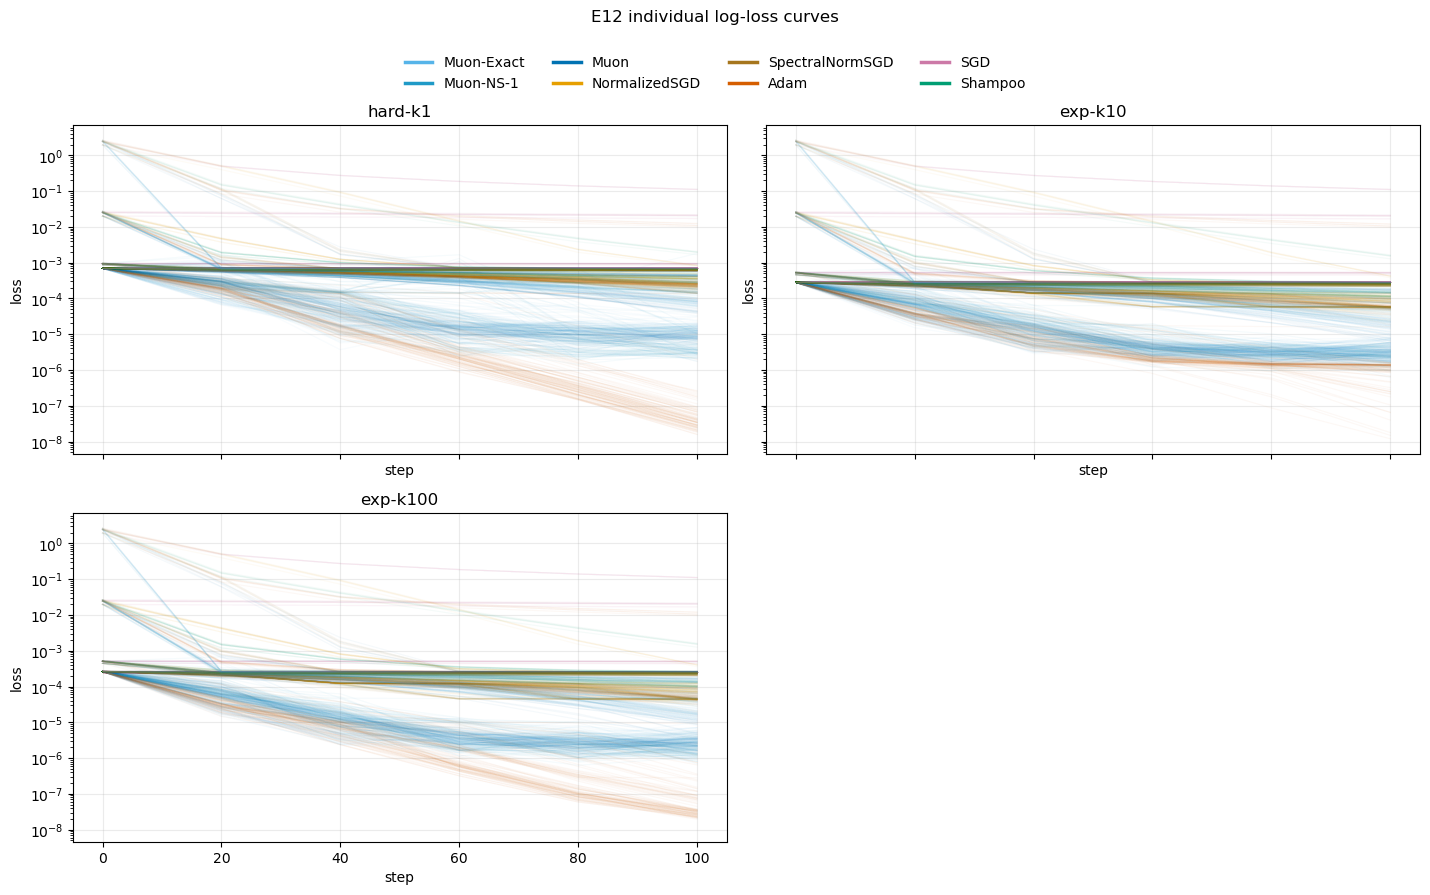

In [5]:
import plotting
from matplotlib.lines import Line2D


def plot_individual_loss_curves(frame, panel_column, *, panel_order=None, title_prefix="Individual loss curves"):
    plot_frame = frame[np.isfinite(frame["loss"])].copy()
    if plot_frame.empty:
        print("No finite loss values to plot.")
        return None, None
    plot_frame["loss_plot"] = plot_frame["loss"].clip(lower=1e-300)
    panels = list(panel_order) if panel_order is not None else sorted(plot_frame[panel_column].dropna().unique())
    ncols = min(2, max(1, len(panels)))
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.2 * nrows), sharex=True, sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    for ax, panel in zip(axes_flat, panels):
        sub = plot_frame[plot_frame[panel_column] == panel].sort_values(["run_id", "step"])
        run_count = max(1, sub["run_id"].nunique())
        alpha = max(0.04, min(0.30, 18.0 / run_count))
        for _, group in sub.groupby("run_id", observed=True, sort=False):
            algo = str(group["algo"].iloc[0])
            ax.plot(
                group["step"],
                group["loss_plot"],
                color=plotting.algorithm_color(algo),
                linewidth=0.85,
                alpha=alpha,
            )
        ax.set_title(str(panel))
        ax.set_xlabel("step")
        ax.set_ylabel("loss")
        ax.set_yscale("log")
        ax.grid(alpha=0.25)
    for ax in axes_flat[len(panels):]:
        ax.axis("off")
    algos = [algo for algo in ALGOS if algo in set(plot_frame["algo"].astype(str))]
    handles = [Line2D([0], [0], color=plotting.algorithm_color(algo), linewidth=2.5, label=algo) for algo in algos]
    if handles:
        fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle(title_prefix, y=1.06 if handles else 1.02)
    fig.tight_layout()
    return fig, axes

fig, axes = plot_individual_loss_curves(runs, "spectrum_case", panel_order=[case["spectrum_case"] for case in SPECTRUM_CASES], title_prefix="E12 individual log-loss curves")
plt.show()


### Figure Discussion: Individual Loss Curves

This figure shows whether optimizers actually reduce the factorization objective under endpoint scale imbalance. Each panel is one target spectrum/condition-number case. Each faint line is one run with a particular first-factor scale, last-factor scale, optimizer, and seed. Color identifies the optimizer. The y-axis is log loss, so vertical separation by even a small visual amount can mean orders-of-magnitude difference. The important pattern is whether one color consistently reaches the lower part of the panel. High flat lines indicate scale settings where that optimizer cannot escape the bad initialization geometry.


### Result Tables

**What this table is:** the final-run summary for each scale cell and optimizer.

- **Rows:** one `(spectrum_case, left_scale, right_scale, optimizer)` group.
- **median_recovery:** lower is better; this is the main success metric.
- **median_balancedness:** lower means adjacent factors have more compatible Gram geometry.
- **median_top_sv_error:** lower means the leading target singular values are recovered better.
- **median_steps / stop_reason:** tells whether the run ended by the budget or early stopping.
- **How to read it:** do not rank methods by loss alone; use recovery first, then balancedness/top-singular-value error as diagnostics.


In [6]:
run_summary = summarize_last_rows(runs, ["run_id"])
summary = run_summary.groupby(["spectrum_case", "left_scale", "right_scale", "algo"], as_index=False, observed=True).agg(
    median_recovery=("recovery_error", "median"), median_balancedness=("balancedness", "median"), median_top_sv_error=("top_sv_error", "median"),
    median_steps=("step", "median"), stop_reason=("stop_reason", lambda x: x.mode().iloc[0] if len(x.mode()) else "")
)
IPython.display.display(summary.sort_values(["spectrum_case", "left_scale", "right_scale", "median_recovery"]))


,spectrum_case,left_scale,right_scale,algo,median_recovery,median_balancedness,median_top_sv_error,median_steps,stop_reason
0,exp-k10,0.0001,0.0001,Adam,0.070621,0.085806,0.063789,100.0,max_steps
3,exp-k10,0.0001,0.0001,Muon-NS-1,0.101298,0.189943,0.074129,100.0,max_steps
1,exp-k10,0.0001,0.0001,Muon,0.107070,0.125365,0.066818,100.0,max_steps
2,exp-k10,0.0001,0.0001,Muon-Exact,0.142519,0.199047,0.080872,100.0,max_steps
7,exp-k10,0.0001,0.0001,SpectralNormSGD,0.454365,0.200811,0.453505,100.0,max_steps
...,...,...,...,...,...,...,...,...,...
593,hard-k1,1.0000,1.0000,Muon,1.000000,0.376454,0.999988,100.0,max_steps
596,hard-k1,1.0000,1.0000,NormalizedSGD,1.094553,0.219828,0.545270,100.0,max_steps
598,hard-k1,1.0000,1.0000,Shampoo,1.679504,0.227038,0.429961,100.0,max_steps
592,hard-k1,1.0000,1.0000,Adam,3.974867,0.244446,2.868668,100.0,max_steps


### Muon-Exact Vs Adam Gap Heatmaps

**What this plot is:** a winner map over endpoint scale imbalance.

- **One cell:** one pair `(left_scale, right_scale)` for a fixed spectrum case, aggregated over seeds.
- **X-axis:** `right_scale`, the initialization scale of the last factor.
- **Y-axis:** `left_scale`, the initialization scale of the first factor.
- **Color value:** `log10(error_MuonExact) - log10(error_Adam)`.
- **Good direction for Muon-Exact:** negative values. Positive values mean Adam has lower recovery error.
- **Decision rule:** the preconditioning story is stronger if negative cells concentrate in imbalanced or ill-conditioned regimes, not only in easy balanced cells.


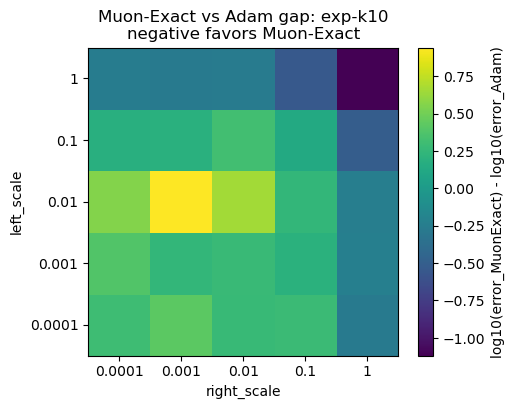

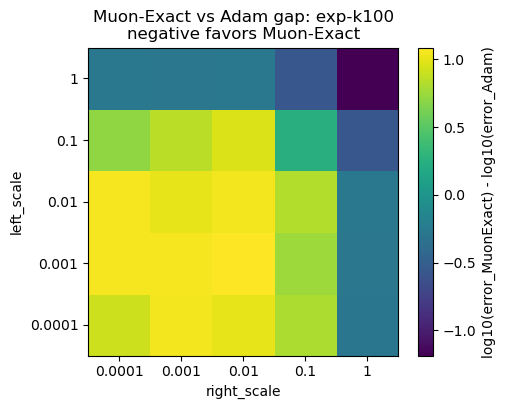

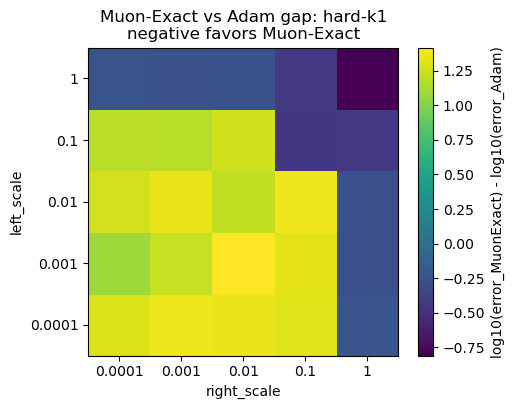

In [7]:
for spectrum_case in sorted(run_summary["spectrum_case"].unique()):
    table = run_summary[run_summary["spectrum_case"] == spectrum_case]
    pivot = table.pivot_table(index=["left_scale", "right_scale", "seed"], columns="algo", values="recovery_error", observed=True).reset_index()
    if {"Muon-Exact", "Adam"}.issubset(pivot.columns):
        pivot["gap"] = np.log10(pivot["Muon-Exact"].clip(lower=1e-12)) - np.log10(pivot["Adam"].clip(lower=1e-12))
        heat = pivot.pivot_table(index="left_scale", columns="right_scale", values="gap", aggfunc="median", observed=True)
        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(heat.values, origin="lower", aspect="auto")
        ax.set_xticks(range(len(heat.columns)), [f"{x:g}" for x in heat.columns])
        ax.set_yticks(range(len(heat.index)), [f"{y:g}" for y in heat.index])
        ax.set_xlabel("right_scale")
        ax.set_ylabel("left_scale")
        ax.set_title(f"Muon-Exact vs Adam gap: {spectrum_case}\nnegative favors Muon-Exact")
        plt.colorbar(im, ax=ax, label="log10(error_MuonExact) - log10(error_Adam)")
        plt.show()


### Figure Discussion: Muon-Exact Vs Adam Gap Heatmaps

Each heatmap is a map over endpoint scale imbalance. The row is `left_scale`, the first factor's initialization scale, and the column is `right_scale`, the last factor's initialization scale. Each cell summarizes multiple seeds at that scale pair. The colorbar value is `log10(error_MuonExact) - log10(error_Adam)`. Negative cells mean Muon-Exact has lower recovery error than Adam; positive cells mean Adam is better. The diagonal cells are balanced endpoint scales. Off-diagonal cells are imbalanced. The preconditioning hypothesis is strongest if Muon-Exact wins especially off the diagonal and under harder spectrum cases.


### Condition Number Scaling

**What this plot is:** sensitivity to target condition number after aggregating over the scale grid.

- **One line:** one optimizer.
- **X-axis:** target condition number `kappa` on a log scale.
- **Y-axis:** median recovery error on a log scale; lower is better.
- **How to read it:** a robust preconditioner should have a lower curve and a flatter slope as `kappa` increases. A steep upward curve means the method degrades quickly on ill-conditioned targets.


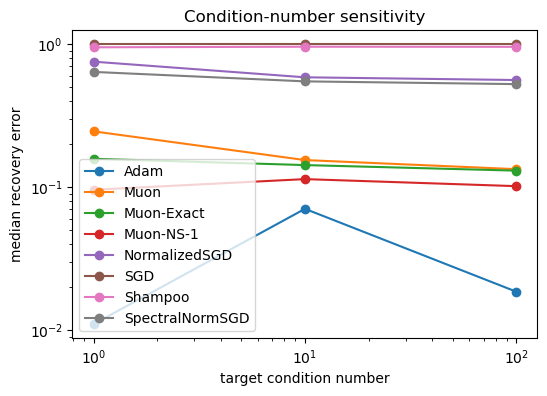

In [8]:
condition_summary = run_summary.groupby(["kappa", "algo"], as_index=False, observed=True).agg(median_recovery=("recovery_error", "median"))
fig, ax = plt.subplots(figsize=(6, 4))
for algo, group in condition_summary.groupby("algo", observed=True):
    ax.plot(group["kappa"], group["median_recovery"], marker="o", label=algo)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("target condition number")
ax.set_ylabel("median recovery error")
ax.set_title("Condition-number sensitivity")
ax.legend()
plt.show()


### Figure Discussion: Condition Number Scaling

This line plot compresses the scale grid and asks how each optimizer behaves as the target matrix becomes more ill-conditioned. Each line is one optimizer. The x-axis is target condition number `kappa`; farther right is harder. The y-axis is median recovery error; lower is better. A method that is robust to conditioning should have a low, relatively flat line. A method whose line rises steeply is sensitive to ill-conditioned spectra. This plot is not about a single scale pair; it is the aggregate condition-number trend.


### Reading The Result

Read E12 in this order: loss curves for optimization behavior, result tables for numerical winners, gap heatmaps for where Muon-Exact beats Adam, and condition-number scaling for whether that advantage survives harder spectra.

This experiment supports the preconditioning story if Muon-Exact or Muon-NS-1 has negative gaps against Adam in imbalanced and ill-conditioned regimes, and if its recovery error grows more slowly with target condition number.


### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| Spectral orthogonalization can act as a preconditioner under endpoint scale imbalance. | Muon-Exact-vs-Adam gap heatmaps and condition-number scaling curves isolate imbalanced and ill-conditioned cases. | Partial | Benefits are regime-dependent and normalization baselines can be competitive. |
| Preconditioning should be evaluated jointly with factor geometry. | The summary table reports recovery, chain balancedness, top-singular-value error, steps, and stop reason. | Yes | Fixed learning rates and endpoint-only scale sweeps limit how broadly the conclusion transfers. |
